# Air Quality Forecasting using LSTM

In [1]:
from google.colab import files
uploaded = files.upload()

Saving air_quality.csv to air_quality.csv


In [2]:
## Importing necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [4]:
## Loading datasetand Data Preprocessing

#Load Dataset
df = pd.read_csv("air_quality.csv")

# Select only needed columns
df = df[['pm2.5', 'TEMP', 'DEWP', 'PRES']]

# Drop missing values
df = df.dropna()

# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Create sequences
def create_sequences(data, time_steps=10):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps, 0])  # pm2.5
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)


In [5]:
## Train-Test the dataset

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [6]:
## Build LSTM Model and Prediction

# Build LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Predict
y_pred = model.predict(X_test)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


835/835 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0023 - val_loss: 6.2543e-04
Epoch 2/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 7.7593e-04 - val_loss: 4.6175e-04
Epoch 3/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 7.1779e-04 - val_loss: 3.8400e-04
Epoch 4/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 6.8305e-04 - val_loss: 4.1143e-04
Epoch 5/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 6.7655e-04 - val_loss: 4.4568e-04
Epoch 6/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.6497e-04 - val_loss: 3.7446e-04
Epoch 7/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 6.4879e-04 - val_loss: 4.1008e-04
Epoch 8/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.6150e-04 - val_loss: 4.6376e-04
Epoch 9/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 6.4653e-04 - val_loss: 3.9603e-04
Epoch 10/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.4014e-04 - val_loss: 4.2575e-04
Epoch 11/20
835/835 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.3503e-04 

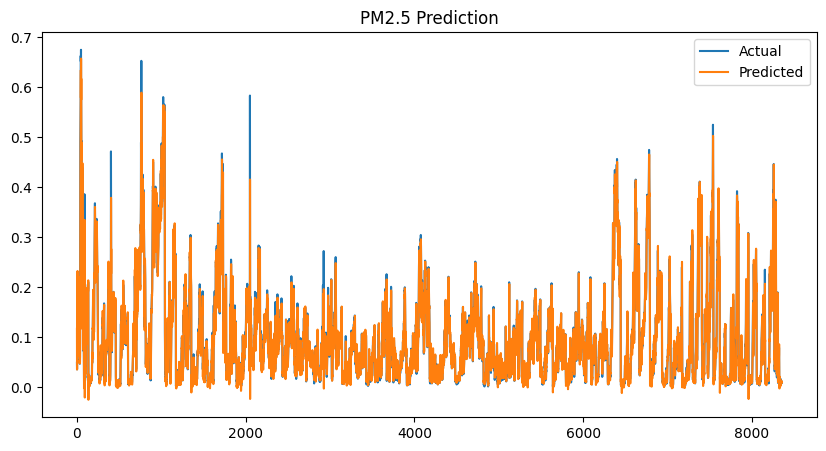

In [7]:
## Visualizations

# Plot results
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("PM2.5 Prediction")
plt.savefig("prediction_plot.png")
plt.show()